In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv("Exam_Score_Prediction.csv")
print(df.head())

   student_id  age  gender   course  study_hours  class_attendance  \
0           1   17    male  diploma         2.78              92.9   
1           2   23   other      bca         3.37              64.8   
2           3   22    male     b.sc         7.88              76.8   
3           4   20   other  diploma         0.67              48.4   
4           5   20  female  diploma         0.89              71.6   

  internet_access  sleep_hours sleep_quality   study_method facility_rating  \
0             yes          7.4          poor       coaching             low   
1             yes          4.6       average  online videos          medium   
2             yes          8.5          poor       coaching            high   
3             yes          5.8       average  online videos             low   
4             yes          9.8          poor       coaching             low   

  exam_difficulty  exam_score  
0            hard        58.9  
1        moderate        54.8  
2       

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(20000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB
None
         student_id           age   study_hours  class_attendance  \
count  20000.000000  20000.000000  200

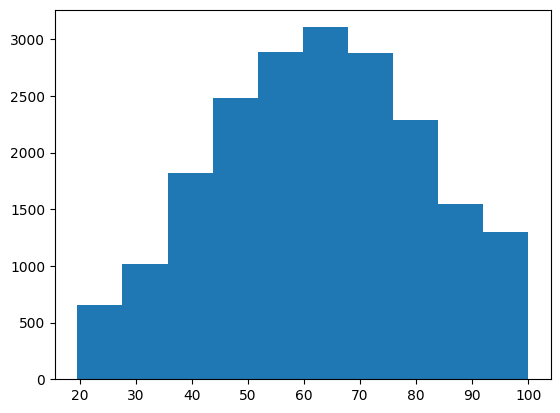

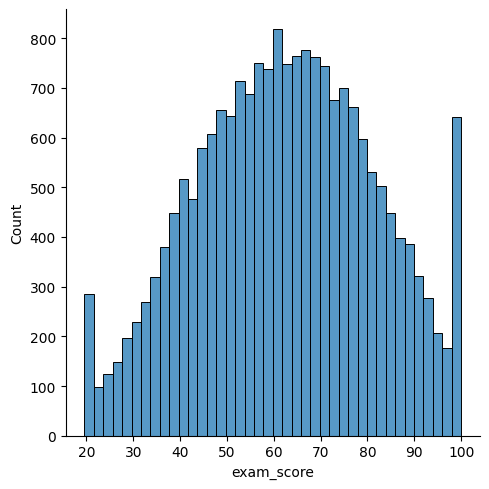

In [4]:
plt.hist(df['exam_score'])
sns.displot(df['exam_score'])
plt.show()

In [5]:
print(df['exam_score'].skew())

-0.04905862218606845


exam_difficulty
moderate    486
easy        308
hard        206
Name: count, dtype: int64


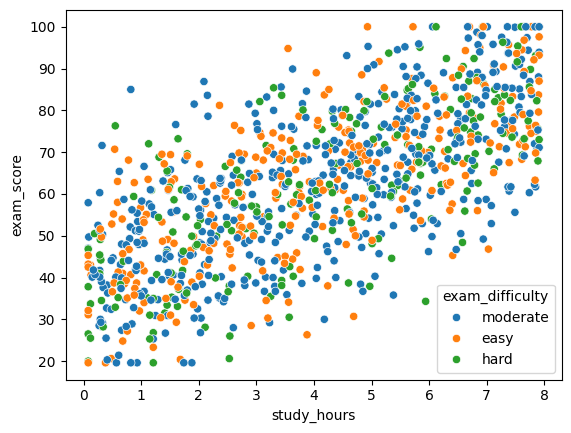

In [20]:
#df = df.sample(1000)
print(df['exam_difficulty'].value_counts())
sns.scatterplot(x = df['study_hours'],y =df['exam_score'],hue=df['exam_difficulty'])
plt.show()

In [18]:
df.groupby('facility_rating')['exam_score'].mean()


facility_rating
high      65.363462
low       58.330440
medium    62.480585
Name: exam_score, dtype: float64

<Axes: xlabel='sleep_quality', ylabel='exam_score'>

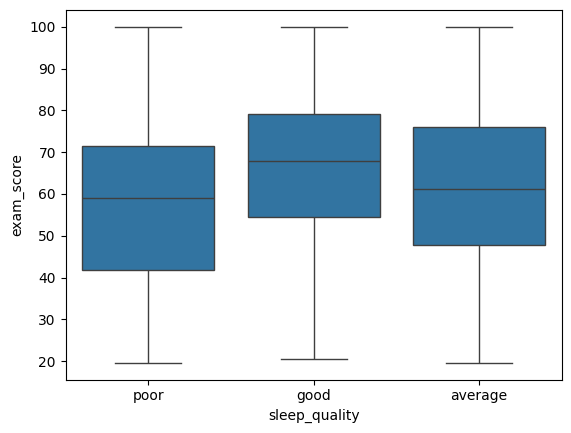

In [25]:
sns.boxplot(x= df['sleep_quality'],y =df['exam_score'])

In [33]:
df.select_dtypes(include='number').corr()['exam_score'].sort_values(ascending=False)

exam_score          1.000000
study_hours         0.704828
class_attendance    0.302965
sleep_hours         0.119238
age                 0.016854
student_id         -0.006557
Name: exam_score, dtype: float64

<Axes: xlabel='class_attendance', ylabel='exam_score'>

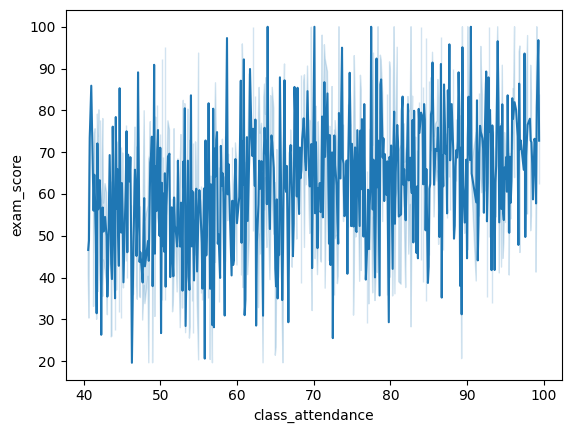

In [28]:
sns.lineplot(x =df['class_attendance'],y =df['exam_score'])

In [55]:
df = df.drop(columns='student_id')

In [56]:
print(df.head())
print(df.shape)

   age  gender   course  study_hours  class_attendance internet_access  \
0   17    male  diploma         2.78              92.9             yes   
1   23   other      bca         3.37              64.8             yes   
2   22    male     b.sc         7.88              76.8             yes   
3   20   other  diploma         0.67              48.4             yes   
4   20  female  diploma         0.89              71.6             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0          7.4          poor       coaching             low            hard   
1          4.6       average  online videos          medium        moderate   
2          8.5          poor       coaching            high        moderate   
3          5.8       average  online videos             low        moderate   
4          9.8          poor       coaching             low        moderate   

   exam_score  
0        58.9  
1        54.8  
2        90.3  
3        29.7  


In [57]:
x = df.iloc[:,0:11]
y = df['exam_score']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_test)

       age  gender course  study_hours  class_attendance internet_access  \
10650   21   other    bba         2.01              48.2             yes   
2041    24  female    bba         6.56              45.9              no   
8668    17   other    bba         4.27              41.0             yes   
1114    18  female    bba         7.28              91.7             yes   
13902   22  female    bca         7.13              64.3             yes   
...    ...     ...    ...          ...               ...             ...   
4073    24  female    bba         5.21              40.6              no   
7442    21    male   b.sc         1.30              42.4             yes   
9999    21   other    bba         5.23              45.4             yes   
1870    17   other  b.com         4.15              75.5             yes   
15196   21    male  b.com         1.66              64.0             yes   

       sleep_hours sleep_quality   study_method facility_rating  \
10650          4.9  